In [1]:
#!/usr/bin/env python
import tifffile
import pandas as pd
import numpy as np
from skimage.measure import regionprops
import warnings
import argparse 
from pathlib import Path
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [8]:
def rotate(mat, angle_deg, center=None, dims=(0, 1)):
    """
    Rotate points in the plane defined by dims by angle_deg degrees.

    Parameters
    ----------
    mat : (n, d) array
        Input coordinates, e.g. PCA coordinates.
    angle_deg : float
        Rotation angle in degrees. Positive = counterclockwise.
    center : array-like of shape (2,), optional
        Center of rotation in the selected dims.
        If None, uses the centroid in those dims.
    dims : tuple of int
        Which two columns to rotate. Default: (0, 1).

    Returns
    -------
    out : (n, d) array
        Rotated copy of mat.
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    Y = out[:, dims]

    if center is None:
        center = Y.mean(axis=0)
    else:
        center = np.asarray(center, dtype=float)

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    out[:, dims] = (Y - center) @ R.T + center
    return out


def standardize(mat, dims=(0, 1)):
    """
    Scale each selected axis independently to span [-1, 1].

    Parameters
    ----------
    mat : (n, d) array
    dims : tuple of int
        Which columns to rescale.

    Returns
    -------
    out : (n, d) array
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    for d in dims:
        x = out[:, d]
        xmin, xmax = x.min(), x.max()
        if np.isclose(xmax, xmin):
            out[:, d] = 0.0
        else:
            out[:, d] = 2 * (x - xmin) / (xmax - xmin) - 1

    return out

In [2]:
image_path = Path('data/mCherryi_1_D_Ey_Kn.tif')
mask_path = Path('data/mCherryi_1_filtered.tif')

In [3]:
if image_path.is_file():
    img = tifffile.imread(image_path)
    if img.ndim == 4:
        # Move channel axis to the end while preserving
        # the order of x and y axes
        img = np.swapaxes(img, 1, 2)
        img = np.swapaxes(img, 2, 3)
else:
    raise FileNotFoundError(f"{image_path} is not found")

In [4]:
logging.info(f"Image shape: {img.shape}")

if mask_path.is_file():
    roi = tifffile.imread(mask_path)
else:
    raise FileNotFoundError(f"{mask_path} is not found")

stats = regionprops(roi, img)

out = {'label': [], 'centroid_x': [], 'centroid_y': [], 'centroid_z': [], 'area': [], 'aspherity': []}
if img.ndim == 4:
    for i in range(img.shape[3]):
        out[f'int_{i}'] = []
else:
    out['int'] = []

for i in stats:
    out['label'].append(i.label)
    out['centroid_x'].append(i.centroid[0])
    out['centroid_y'].append(i.centroid[1])
    out['centroid_z'].append(i.centroid[2])

    with warnings.catch_warnings():
      warnings.simplefilter("ignore")
      out['area'].append(i.area_convex)
        
    if img.ndim == 3:
      out['int'].append(i.intensity_mean)
    else:
      for j in range(img.shape[3]):
        out[f'int_{j}'].append(i.intensity_mean[j])

    out['aspherity'].append(i.axis_major_length/i.equivalent_diameter_area)

outdf = pd.DataFrame(out)

2026-05-22 22:37:59,532 - INFO - Image shape: (103, 1024, 1024, 3)


In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [11]:
pca = PCA(n_components=3, svd_solver='auto')
pcaobj = pca.fit_transform(outdf[['centroid_x', 'centroid_y', 'centroid_z']].to_numpy())

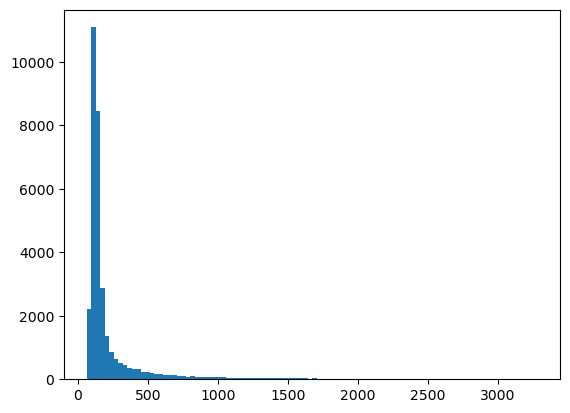

In [24]:
_ = plt.hist(outdf['int_2'], bins = 100)

In [ ]:
d_thres = 1500
ey_thres = 1000
kn_thres = 625

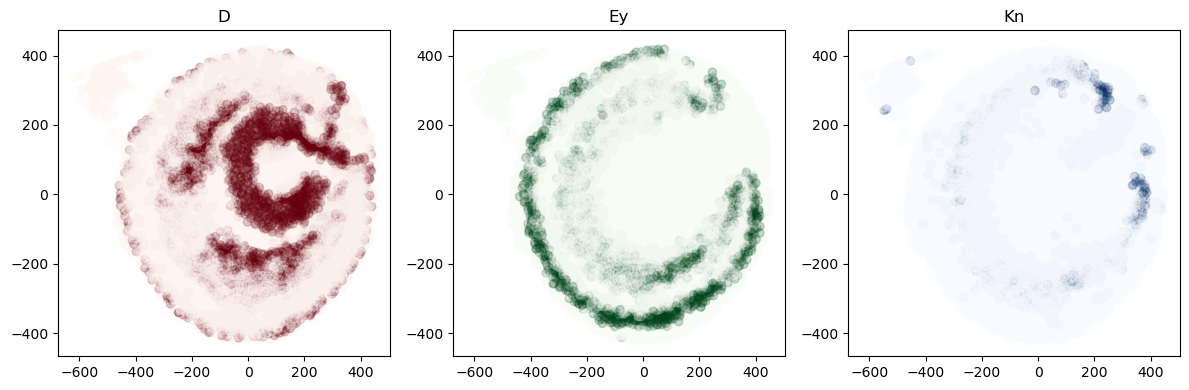

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot the scatter of 3 intensity channels, and the product of the 3 channels
_ = ax1.scatter(pcaobj[:, 0], pcaobj[:, 1], c=outdf['int_0'] > d_thres, cmap='Reds', alpha = 0.2)
ax1.set_title('D')
_ = ax2.scatter(pcaobj[:, 0], pcaobj[:, 1], c=outdf['int_1'] > ey_thres, cmap='Greens', alpha = 0.2)
ax2.set_title('Ey')
_ = ax3.scatter(pcaobj[:, 0], pcaobj[:, 1], c=outdf['int_2'] > kn_thres, cmap='Blues', alpha = 0.2)
ax3.set_title('Kn')
plt.tight_layout()
plt.show()


In [35]:
outdf['Tm5e'] = (outdf['int_1'] > 1500) & (outdf['int_2'] > 750)

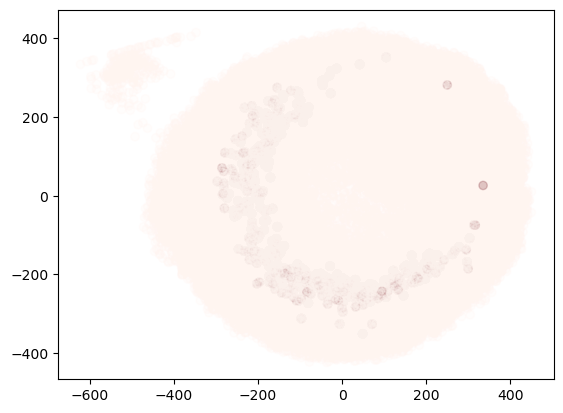

In [36]:
_ = plt.scatter(pcaobj[:, 0], pcaobj[:, 1], c=outdf['Tm5e'], cmap='Reds', alpha = 0.2)